# Contents
1. **Single Layer Neural Networks**. We look at how a single layer network performs on a toy dataset
2. **Multilayer Perceptrons**. We look at how multiple layers perform on toy datasets
2. **Handwritten digit recognition in sklearn**. Learning to classify numbers using the libraries in sklearn
2. **Handwritten digit recognition in Pytorch**. Learning to classify numbers using libraries in Pytorch

Finally, try working through some tutorials in Pytorch and play around with the different hyperparameter choices. Links to tutorials are at the end of the notebook.

# Single Layer Neural Network

In this question we apply a single-layer neural network to a linearly separable toy data set.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

We start by generating  and visualizing some data

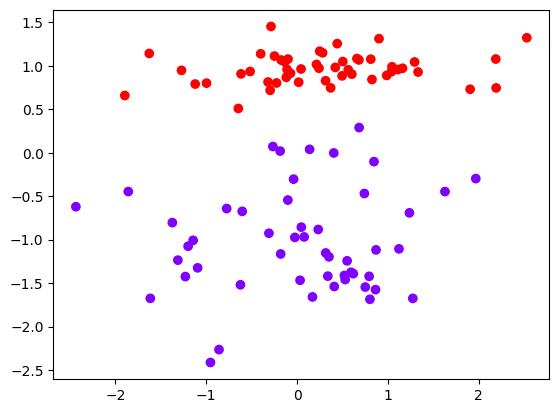

In [3]:
X1, y1 = make_classification(n_features=2, n_redundant=0, \
            n_informative=1, random_state=1,n_clusters_per_class=1)
fig1, ax1 = plt.subplots()
ax1.scatter(X1[:,0],X1[:,1],c=y1, cmap='rainbow')
plt.show()

Notice that the two classes can clearly be separated by a single line. We can now fit a single layer neural network to the data.

In [4]:
nn1=Perceptron(alpha=1, max_iter=1000)
model=nn1.fit(X1,y1)

(Optional) Plot the line that the perceptron is modelling. Look at the documentation to find out how you can get the values of the weights and the bias.

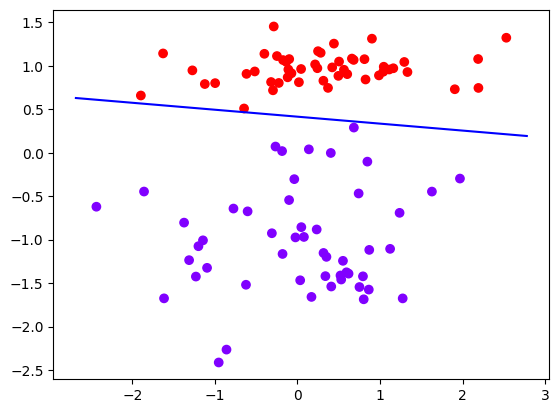

In [5]:
weights = model.coef_[0]
biases = model.intercept_[0]

x_max, x_min = ax1.get_xlim()
xs = np.linspace(x_min, x_max, 100)

ys = -(weights[0] * xs + biases) / weights[1]

# line  = X1[:, 0] * weights[] + weights[1]
plt.figure()
plt.plot(xs, ys, 'b')
plt.scatter(X1[:,0],X1[:,1],c=y1, cmap='rainbow')
plt.show()


We can visualise the performance of this network again using a scatter plot, and colour the points using predicted class. Is the network able to give the right classification for each point?

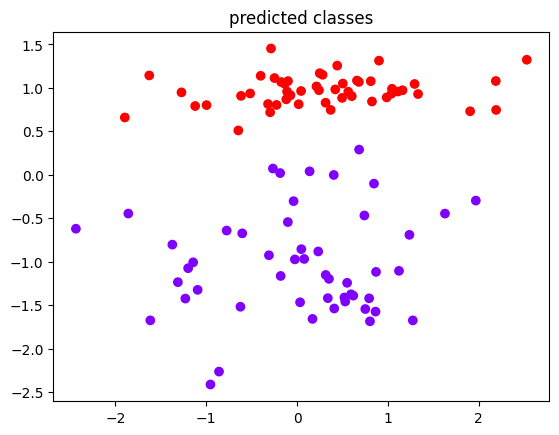

Accuracy score: 1.0


In [6]:
ypred1=model.predict(X1)
# TODO: Make a scatter plot of the predictions.
plt.figure()
plt.scatter(X1[:,0],X1[:,1],c=ypred1, cmap='rainbow')
plt.title('predicted classes')
plt.show()

# How do the predictions compare with the ground truth? Compute the accuracy to compare
accuracy = accuracy_score(y1, ypred1)
print('Accuracy score:', accuracy )

# Multi-Layer NN on Toy Problems
In this question we consider two toy problems in which the classes are not linearly separable. In the first example the two classes form moon shapes.

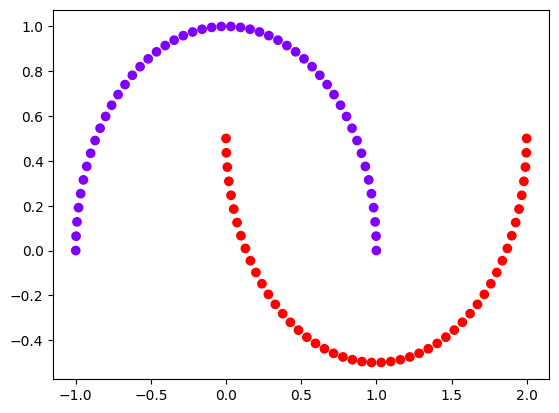

In [7]:
X2, y2 = make_moons()
fig2, ax2 = plt.subplots()
ax2.scatter(X2[:,0],X2[:,1],c=y2, cmap='rainbow')

Try fitting a single-layer neural network to the data.
Comment on the performance and hypothesise what might be the source of the errors.

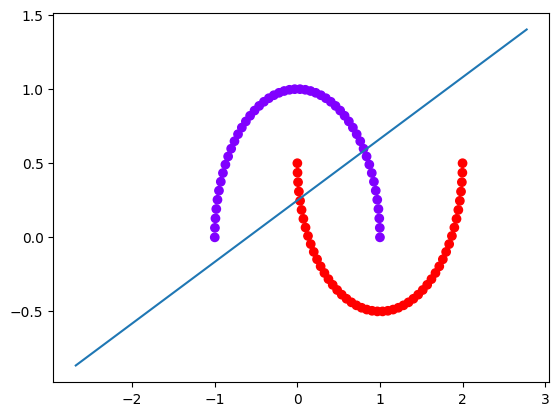

Accuracy Score: 0.86


In [8]:
# Define single layer NN
nn2=Perceptron(alpha=1, max_iter=1000)
nn2.fit(X2, y2)

# Extract weights and biases
weights = nn2.coef_[0]
bias = nn2.intercept_[0]

# Define boundary using weights and bias
x_max2, x_min2 = ax1.get_xlim()
xs2 = np.linspace(x_min2, x_max2, 100)
ys2 = -(weights[0]*xs + bias)/weights[1]

# Plot boundary 
plt.figure()
plt.scatter(X2[:,0],X2[:,1],c=y2, cmap='rainbow')
plt.plot(xs2, ys2)
plt.show()

# Get accuracy
y_pred2 = nn2.predict(X2)
acc2 = accuracy_score(y_pred=y_pred2, y_true=y2)
print('Accuracy Score:', acc2)


We can now try to fit an multi-layer NN to the same data.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


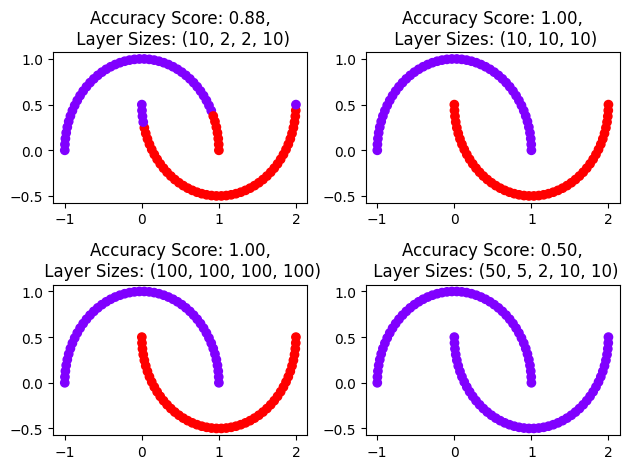

In [9]:
hidden_layer_sizes = [(10, 2, 2, 10), (10, 10, 10), (100, 100, 100, 100), (50, 5, 2, 10, 10)]

fig2_2, ((ax_a, ax_b),(ax_c,ax_d)) = plt.subplots(2,2)
axes = [ax_a, ax_b, ax_c, ax_d]
for i,hidden_layer_size in enumerate(hidden_layer_sizes):
    nn2=MLPClassifier(alpha=1,hidden_layer_sizes=hidden_layer_size, max_iter=1000)
    model2=nn2.fit(X2,y2)
    ypred2_2=model2.predict(X2)

    # Compute accuracy
    acc2_2 = accuracy_score(ypred2_2, y2)

    # Plot
    axes[i].scatter(X2[:,0],X2[:,1],c=ypred2_2, cmap='rainbow')
    axes[i].set_title(f'Accuracy Score: {acc2_2:.2f},\n Layer Sizes: {hidden_layer_size}')

fig2_2.tight_layout()
plt.show()  




This NN has 4 hidden layers each with 10 neurons. The parameter
`hidden_layer_sizes=(x,y,z, ...)` identifies the number of neurons in each layer. Try experimenting with different configurations of hidden layers to see the effect on performance.

Investigate the parameter `activation`. What are the different activation functions?

In [10]:
print('Activation function(s) used:', model2.activation)

Activation function(s) used: relu


The activation functions are:

We now introduce another toy classification problem based on classes in the form of two circles. Experiment with using different NN architectures to fit this data and plot the results.

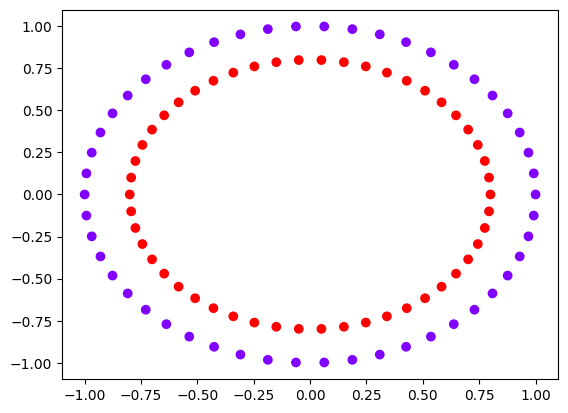

In [11]:
X3, y3 = make_circles()
fig3, ax3 = plt.subplots()
ax3.scatter(X3[:,0],X3[:,1],c=y3, cmap='rainbow')
plt.show()

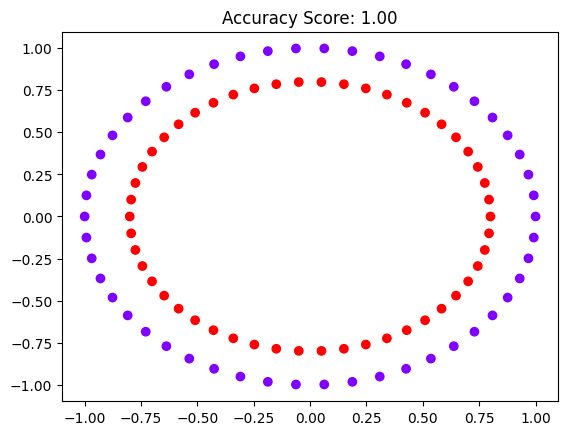

In [12]:
# 
nn3=MLPClassifier(alpha=1,hidden_layer_sizes=(10, 100, 100, 10), max_iter=1000)
model3=nn3.fit(X3,y3)
ypred3=model3.predict(X3)

# Compute accuracy
acc3 = accuracy_score(ypred3, y3)


# Plot
plt.scatter(X3[:,0],X3[:,1],c=ypred3, cmap='rainbow')
plt.title(f'Accuracy Score: {acc3:.2f}')
plt.show()



# Handwritten Digit Recognition
The data set contains images of hand-written digits. There are 10 classes where each class refers to a digit. Preprocessing programs were used to extract normalized bitmaps of handwritten digits from a preprinted form.  32 × 32 bitmaps are divided into non-overlapping blocks of 4 × 4 and the number of on pixels are counted in each block. This generates an input matrix of 8 × 8 where each element is an integer in the range 0...16.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.datasets import load_digits
digits = load_digits()



Divide the data into training and test sets, fit a NN to the training data and evaulate its accuracy on both training and test data.

In [14]:
train_x, test_x, train_y, test_y = train_test_split(digits['data'], digits['target'], test_size=0.2)

nn4 = MLPClassifier(alpha=1, activation='tanh', hidden_layer_sizes=(32, 64, 128, 64), max_iter=1000)
print(train_x.shape)
print(train_y.shape)
model4 = nn4.fit(train_x, train_y)
ypred4 = model4.predict(test_x)


# Compute accuracy
acc4 = accuracy_score(ypred4, test_y)
print(acc4)





(1437, 64)
(1437,)
0.9611111111111111


It is also useful to plot a time series graph of the loss function (error) against iteration.

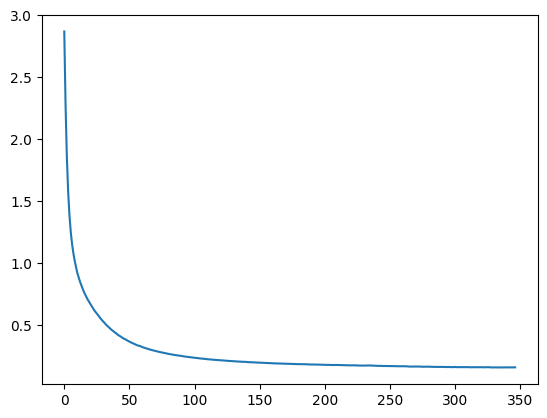

In [15]:
loss_values = model4.loss_curve_
plt.figure()
plt.plot(loss_values)
plt.show()

Try experimenting with different architectures and activation functions.

## Handwritten digit recognition in Pytorch
This is an excerpt from a tutorial in Pytorch, available at https://docs.pytorch.org/tutorials/index.html. Pytorch has lots of tutorials if you want to investigate.

In this tutorial, you are asked to:

1. Load a prebuilt dataset.
2. Build a neural network machine learning model that classifies images.
2. Train this neural network.
2. Evaluate the accuracy of the model.


We firstly import Pytorch. You may need to install Pytorch first.

In [16]:
pip install torch

In [17]:
import torch
print("PyTorch version:", torch.__version__)


PyTorch version: 2.9.0+cu126


In [18]:
pip install torchvision

## Load the MNIST digits dataset

Load the dataset and convert data from integgers into floating point numbers:

In [19]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import numpy as np

# Load MNIST
train_ds = MNIST(root="./data", train=True, download=True, transform=ToTensor())
test_ds  = MNIST(root="./data", train=False, download=True, transform=ToTensor())

# Convert to numpy (to match your existing code style)
x_train = train_ds.data.numpy() / 255.0
y_train = train_ds.targets.numpy()

x_test = test_ds.data.numpy() / 255.0
y_test = test_ds.targets.numpy()


100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.96MB/s]


## Build a machine learning model

Here, the model is a sequential model, meaning that it has a feed-forward architecture rather than a recurrent architecture or otherwise.

We set up a Sequential model and then add layers to it. Each layer can have different types: Flatten, Dense, Dropout. Look through the documentation for each layer to find out about them.

In [20]:
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),          # (28, 28) -> 784
    nn.Linear(28 * 28, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 10)
)

For each datapoint, the model returns a vector of logits or log-odds scores, one for each class. Below, we make predictions for just one datapoint.

In [21]:
model.eval()  # set eval mode (important for Dropout)

with torch.no_grad():
    x = torch.tensor(x_train[:1], dtype=torch.float32)
    predictions = model(x).numpy()

predictions

array([[ 0.08000423, -0.18024668,  0.00423061,  0.01786685, -0.02959627,
        -0.04521003, -0.03402806, -0.07681368, -0.04082242, -0.03000285]],
      dtype=float32)

The tf.nn.softmax function converts these logits to probabilities for each class - now we have the probabilities that this datapoint belongs to each class.

In [22]:
torch.softmax(torch.tensor(predictions), dim=1).numpy()

array([[0.11179128, 0.08617522, 0.10363343, 0.10505627, 0.10018645,
        0.09863432, 0.09974343, 0.09556586, 0.09906804, 0.10014573]],
      dtype=float32)

For training the model, we need to define a loss function. We will use losses.SparseCategoricalCrossentropy, which takes a vector of logits and a True index and returns a scalar loss for each example.

In [23]:
loss_fn = nn.CrossEntropyLoss()

This loss is equal to the negative log probability of the true class: The loss is zero if the model is sure of the correct class.

This untrained model gives probabilities close to random (1/10 for each class), so the initial loss should be close to `-tf.math.log(1/10) ~= 2.3`.

In [24]:
y = torch.tensor(y_train[:1], dtype=torch.long)
pred = torch.tensor(predictions, dtype=torch.float32)

loss_fn(pred, y).item()

2.316336154937744

Before we start training, we compile the model, setting the kind of optimizer we want to use (`adam`, the loss function, as set up above, and the metric we want to measure (`accuracy`).

In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def accuracy(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()


Train and evaluate your model

In [ ]:
model.train()

x = torch.tensor(x_train, dtype=torch.float32)
y = torch.tensor(y_train, dtype=torch.long)

epochs = 500
for epoch in range(epochs):
    logits = model(x)
    loss = loss_fn(logits, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    acc = (torch.argmax(logits, dim=1) == y).float().mean().item()
    print(f"Epoch {epoch+1}/{epochs} - loss: {loss.item():.4f} - acc: {acc:.4f}")


Epoch 1/500 - loss: 2.3064 - acc: 0.0994
Epoch 2/500 - loss: 2.2141 - acc: 0.3713
Epoch 3/500 - loss: 2.1246 - acc: 0.5446
Epoch 4/500 - loss: 2.0331 - acc: 0.6174
Epoch 5/500 - loss: 1.9389 - acc: 0.6582
Epoch 6/500 - loss: 1.8419 - acc: 0.6898
Epoch 7/500 - loss: 1.7431 - acc: 0.7170
Epoch 8/500 - loss: 1.6452 - acc: 0.7390
Epoch 9/500 - loss: 1.5479 - acc: 0.7554
Epoch 10/500 - loss: 1.4532 - acc: 0.7726
Epoch 11/500 - loss: 1.3620 - acc: 0.7807
Epoch 12/500 - loss: 1.2754 - acc: 0.7867
Epoch 13/500 - loss: 1.1939 - acc: 0.7923
Epoch 14/500 - loss: 1.1183 - acc: 0.7974
Epoch 15/500 - loss: 1.0479 - acc: 0.7996
Epoch 16/500 - loss: 0.9837 - acc: 0.8031
Epoch 17/500 - loss: 0.9264 - acc: 0.8073
Epoch 18/500 - loss: 0.8733 - acc: 0.8100
Epoch 19/500 - loss: 0.8235 - acc: 0.8167
Epoch 20/500 - loss: 0.7811 - acc: 0.8206
Epoch 21/500 - loss: 0.7434 - acc: 0.8240
Epoch 22/500 - loss: 0.7075 - acc: 0.8286
Epoch 23/500 - loss: 0.6764 - acc: 0.8337
Epoch 24/500 - loss: 0.6491 - acc: 0.8369
E

Checks the model's performance



In [ ]:
model.eval()

x = torch.tensor(x_test, dtype=torch.float32)
y = torch.tensor(y_test, dtype=torch.long)

with torch.no_grad():
    logits = model(x)
    loss = loss_fn(logits, y)
    acc = (torch.argmax(logits, dim=1) == y).float().mean().item()

print(f"Test loss: {loss.item():.4f}")
print(f"Test accuracy: {acc:.4f}")


The model is now trained to almost 98% accuracy. We evaluated the mode on the test set. Can you evaluate it on the training set? Try altering the structure of the network that we set up. Can you change the performance? It will be quite difficult to improve on 98% - but see if you can make it worse! What sort of changes can you make? What effect do they have?